In [11]:
from google.colab import drive
drive.mount('/content/drive')

import csv
import re
from collections import Counter, defaultdict
from pathlib import Path
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Leyendo /content/drive/MyDrive/Dragons/Data/White list español ...
  A.csv -> familia A: 71484 artículos acumulados, 160 medios acumulados
  B1.csv -> familia B: 32001 artículos acumulados, 144 medios acumulados
  B2 - 1.csv -> familia B2 - 1: 7443 artículos acumulados, 123 medios acumulados
  B2 - 2.csv -> familia B2 - 2: 6305 artículos acumulados, 125 medios acumulados
  C1.csv -> familia C: 12641 artículos acumulados, 136 medios acumulados
  C2.csv -> familia C: 23088 artículos acumulados, 142 medios acumulados
  D1.csv -> familia D: 18154 artículos acumulados, 119 medios acumulados
  D2.csv -> familia D: 38709 artículos acumulados, 137 medios acumulados
  E.csv -> familia E: 15261 artículos acumulados, 140 medios acumulados
  F.csv -> familia F: 10618 artículos acumulados, 135 medios acumulados
  G.csv -> familia G: 24726 artículos acumulados, 144 medios acumulados
  H.csv -> familia H: 12999 artículos acumulados, 112 medios acumulados
  I.csv -> familia I: 32939 artículos acumulad

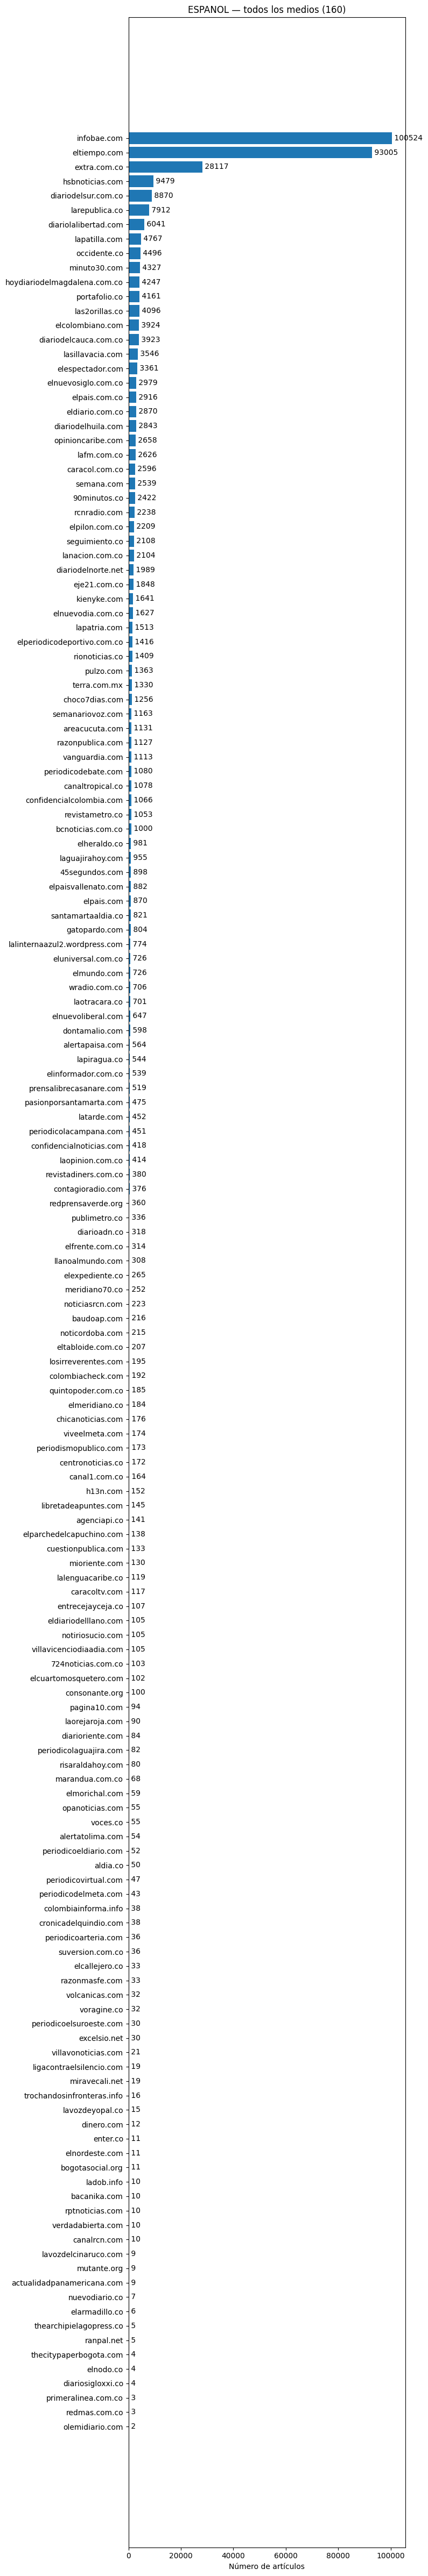

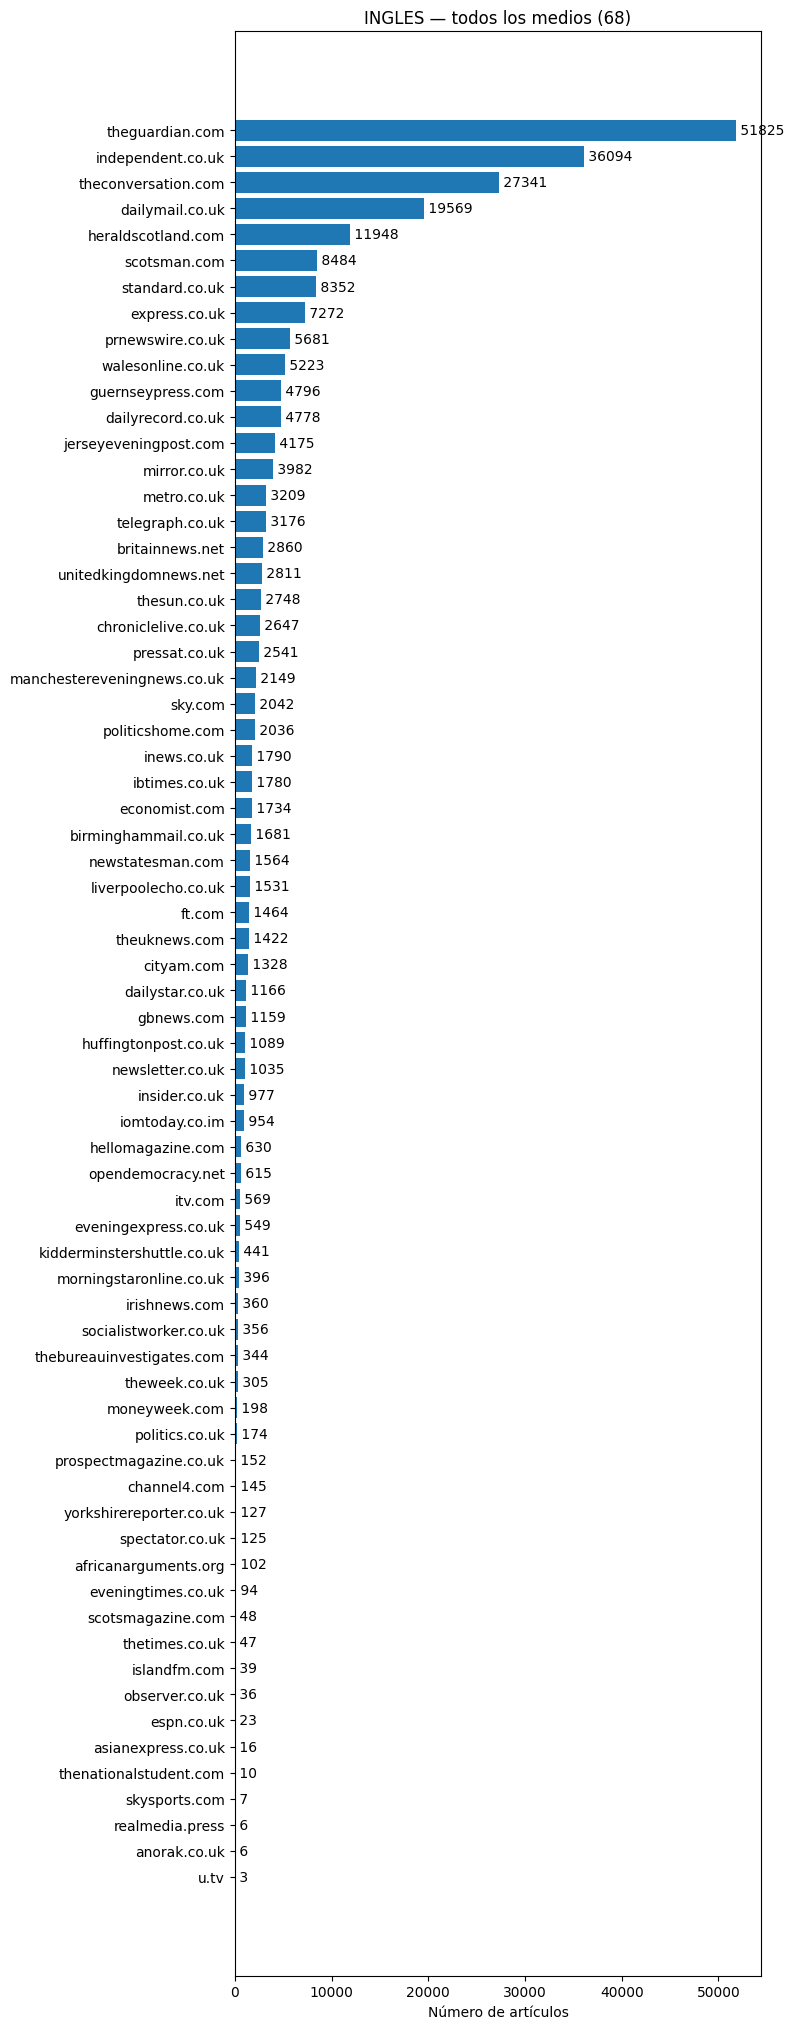

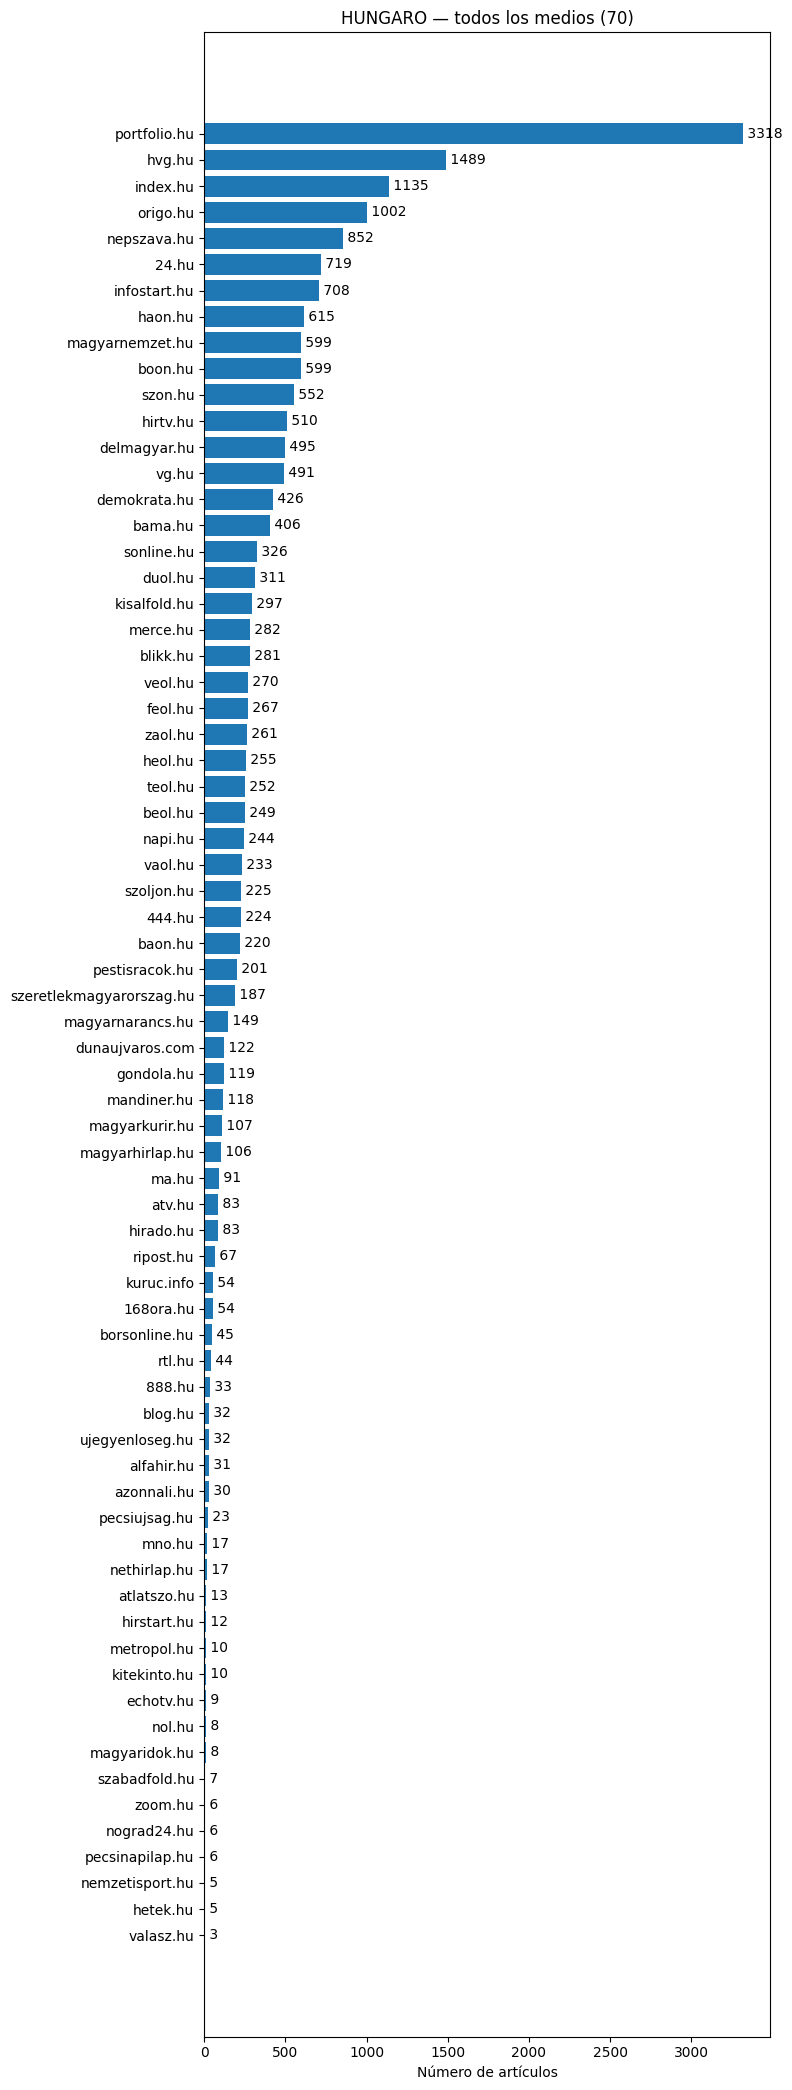

Gráficos guardados en /content/drive/MyDrive/Dragons/Data/graficos


In [13]:
MEDIA_FIELD = "media_name"

BASE_DIR = Path("/content/drive/MyDrive/Dragons/Data")

if not BASE_DIR.exists():
    raise FileNotFoundError(f"No existe BASE_DIR: {BASE_DIR}. Contenido de su padre: "
                             f"{list(BASE_DIR.parent.iterdir()) if BASE_DIR.parent.exists() else 'tampoco existe el padre'}")

CARPETAS = {
    "ESPANOL": BASE_DIR / "White list español",
    "INGLES": BASE_DIR / "White list ingles",
    "HUNGARO": BASE_DIR / "White list hungaro",
}

for idioma, carpeta in CARPETAS.items():
    if not carpeta.exists():
        print(f"[AVISO] no existe la carpeta para {idioma}: {carpeta}")

# Familias que quedaron partidas en el txt original por límite de caracteres,
# y deben fusionarse en una sola familia antes de contar.
FAMILIAS_PARTIDAS = {
    "ESPANOL": {
        "B1": "B",
        "B2-1": "B",
        "B2-2": "B",
        "C1": "C",
        "C2": "C",
        "D1": "D",
        "D2": "D",
    },
    "INGLES": {
        "B1": "B",
        "B2": "B",
    },
    "HUNGARO": {},
}


def leer_familia(archivo: Path, idioma: str) -> str:
    stem = archivo.stem
    return FAMILIAS_PARTIDAS.get(idioma, {}).get(stem, stem)


def normalizar_medio(nombre: str) -> str:
    n = nombre.strip().lower()
    n = re.sub(r"^www\.", "", n)
    n = n.rstrip("/")
    return n


# --- Lectura ---
# idioma -> familia -> Counter(medio -> n_articulos)
conteo = defaultdict(lambda: defaultdict(Counter))

for idioma, carpeta in CARPETAS.items():
    if not carpeta.exists():
        continue
    print(f"Leyendo {carpeta} ...")
    for archivo in sorted(carpeta.glob("*.csv")):
        familia = leer_familia(archivo, idioma)
        with open(archivo, encoding="utf-8-sig") as f:
            for row in csv.DictReader(f):
                medio = (row.get(MEDIA_FIELD) or "").strip()
                if not medio:
                    continue
                conteo[idioma][familia][normalizar_medio(medio)] += 1
        print(f"  {archivo.name} -> familia {familia}: "
              f"{sum(conteo[idioma][familia].values())} artículos acumulados, "
              f"{len(conteo[idioma][familia])} medios acumulados")

# --- Resumen: idioma | familia | n_medios | n_articulos ---
filas_resumen = []
for idioma in conteo:
    for familia, medios in conteo[idioma].items():
        filas_resumen.append({
            "idioma": idioma,
            "familia": familia,
            "n_medios": len(medios),
            "n_articulos": sum(medios.values()),
        })
filas_resumen.sort(key=lambda x: (x["idioma"], x["familia"]))

print("\nidioma   familia   n_medios   n_articulos")
for f in filas_resumen:
    print(f"{f['idioma']:8} {f['familia']:8} {f['n_medios']:9} {f['n_articulos']:12}")

with open(BASE_DIR / "resumen_medios_por_familia.csv", "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=["idioma", "familia", "n_medios", "n_articulos"])
    writer.writeheader()
    writer.writerows(filas_resumen)

# --- Detalle: idioma, familia, medio, n_articulos ---
filas_detalle = []
for idioma in conteo:
    for familia, medios in conteo[idioma].items():
        for medio, n in medios.items():
            filas_detalle.append({
                "idioma": idioma,
                "familia": familia,
                "medio": medio,
                "n_articulos": n,
            })
filas_detalle.sort(key=lambda x: (x["idioma"], x["familia"], -x["n_articulos"]))

with open(BASE_DIR / "medios_por_familia.csv", "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=["idioma", "familia", "medio", "n_articulos"])
    writer.writeheader()
    writer.writerows(filas_detalle)

print("\nGenerados: resumen_medios_por_familia.csv, medios_por_familia.csv")

# --- Total por idioma (sumando todas las familias) ---
filas_total_idioma = []
for idioma in conteo:
    medios_unicos = set()
    n_articulos = 0
    for familia, medios in conteo[idioma].items():
        medios_unicos.update(medios)
        n_articulos += sum(medios.values())
    filas_total_idioma.append({
        "idioma": idioma,
        "n_medios": len(medios_unicos),
        "n_articulos": n_articulos,
    })
filas_total_idioma.sort(key=lambda x: x["idioma"])

print("\nidioma   n_medios   n_articulos")
for f in filas_total_idioma:
    print(f"{f['idioma']:8} {f['n_medios']:9} {f['n_articulos']:12}")

with open(BASE_DIR / "total_por_idioma.csv", "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=["idioma", "n_medios", "n_articulos"])
    writer.writeheader()
    writer.writerows(filas_total_idioma)

print("Generado: total_por_idioma.csv")

# --- Gráfico general por idioma: todos los medios, sumando todas las familias ---
CARPETA_GRAFICOS = BASE_DIR / "graficos"
CARPETA_GRAFICOS.mkdir(exist_ok=True)

for idioma in conteo:
    total_por_medio = Counter()
    for familia, medios in conteo[idioma].items():
        total_por_medio.update(medios)

    items = total_por_medio.most_common()
    nombres = [m for m, _ in items]
    valores = [n for _, n in items]

    alto = max(4, 0.3 * len(nombres))
    fig, ax = plt.subplots(figsize=(8, alto))
    ax.barh(nombres, valores)
    ax.invert_yaxis()
    ax.set_xlabel("Número de artículos")
    ax.set_title(f"{idioma} — todos los medios ({len(nombres)})")
    for i, v in enumerate(valores):
        ax.text(v, i, f" {v}", va="center")
    plt.tight_layout()

    salida = CARPETA_GRAFICOS / f"{idioma}_general.png"
    plt.savefig(salida, dpi=150)
    plt.show()
    plt.close(fig)

print(f"Gráficos guardados en {CARPETA_GRAFICOS}")